# Proyek Klasifikasi Gambar: Intel Image Classification Dataset.
- **Nama:** Muh. Arifandi
- **Email:** arif76440@gmail.com
- **ID Dicoding:** arif76440

## Domain Proyek

Perkembangan teknologi Deep Learning memungkinkan komputer melakukan pengenalan objek visual dengan tingkat akurasi yang tinggi. Salah satu implementasi Deep Learning yang paling populer dalam bidang Computer Vision adalah klasifikasi gambar menggunakan Convolutional Neural Network (CNN).

Pada proyek ini dibangun model klasifikasi gambar pemandangan alam menggunakan Intel Image Classification Dataset dengan lima kategori yaitu forest, glacier, mountain, sea, dan street.

Dataset dipilih karena memiliki jumlah gambar yang besar, variasi visual yang beragam, serta ukuran gambar asli yang tidak seragam sehingga cocok digunakan untuk melatih model klasifikasi gambar pada kasus nyata.

Selain membangun model klasifikasi, proyek ini juga melakukan konversi model ke format SavedModel, TensorFlow Lite, dan TensorFlow.js agar model dapat digunakan pada berbagai platform deployment seperti cloud, mobile, dan browser.

# Business Understanding

## Problem Statement

1. Bagaimana membangun model CNN untuk melakukan klasifikasi gambar pemandangan alam?

2. Bagaimana meningkatkan kemampuan model agar mampu melakukan generalisasi dengan baik terhadap gambar baru?

3. Bagaimana melakukan deployment model ke berbagai platform menggunakan SavedModel, TensorFlow Lite, dan TensorFlow.js?

## Goals

1. Mengembangkan model klasifikasi gambar berbasis Sequential CNN menggunakan pendekatan Transfer Learning MobileNetV2.

2. Mencapai akurasi model minimal 85% pada data testing.

3. Mengimplementasikan preprocessing dan data augmentation untuk meningkatkan kemampuan generalisasi model.

4. Menghasilkan model yang dapat digunakan pada berbagai platform deployment seperti TensorFlow SavedModel, TensorFlow Lite, dan TensorFlow.js.

## Solution Statements

Solusi yang digunakan pada proyek ini adalah:

- Menggunakan arsitektur Sequential berbasis Transfer Learning MobileNetV2 untuk meningkatkan performa klasifikasi gambar.

- Mengimplementasikan data augmentation untuk meningkatkan variasi data training dan kemampuan generalisasi model.

- Menggunakan callback seperti EarlyStopping, ReduceLROnPlateau, dan ModelCheckpoint untuk meningkatkan stabilitas proses training.

- Menggunakan GlobalAveragePooling2D untuk mengurangi jumlah parameter agar model lebih ringan dan efisien.

- Mengonversi model ke format SavedModel, TensorFlow Lite, dan TensorFlow.js untuk mendukung deployment pada berbagai platform.

## Data Understanding

Dataset yang digunakan adalah Intel Image Classification Dataset.

Link Dataset:
https://www.kaggle.com/datasets/puneet6060/intel-image-classification

Pada proyek ini digunakan lima kategori gambar pemandangan alam, yaitu:

1. forest
2. glacier
3. mountain
4. sea
5. street

Dataset memiliki ukuran gambar yang tidak seragam sehingga diperlukan preprocessing berupa resize gambar sebelum proses training dilakukan.

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install -q kaggle
!pip install -q tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2 

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import tensorflowjs as tfjs

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.preprocessing import image

## Data Preparation

### Data Loading

#### Upload Kaggle API

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muharifandi","key":"d71b66e0dd0261c750b3cf05fdbe31d2"}'}

#### Setup Kaggle API

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

#### Download Dataset

In [5]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 184MB/s]



#### Extract Dataset

In [6]:
!unzip -q intel-image-classification.zip

#### Memilih 5 Kelas Dataset

In [7]:
selected_classes = [
    'forest',
    'glacier',
    'mountain',
    'sea',
    'street'
]

source_dir = '/content/seg_train/seg_train'

filtered_dir = '/content/intel_5class'

os.makedirs(filtered_dir, exist_ok=True)

for cls in selected_classes:

    shutil.copytree(
        os.path.join(source_dir, cls),
        os.path.join(filtered_dir, cls)
    )

print("5 kelas berhasil dibuat")

5 kelas berhasil dibuat


#### Menentukan Direktori Dataset

In [8]:
base_dir = '/content/intel_5class'

### Data Understanding

#### Menampilkan Kelas Dataset

In [9]:
classes = sorted(os.listdir(base_dir))
classes

['forest', 'glacier', 'mountain', 'sea', 'street']

### Analisis Dataset

Dataset Intel Image Classification terdiri dari sekitar 25.000 gambar dengan 6 kategori pemandangan alam:

- buildings
- forest
- glacier
- mountain
- sea
- street

Dataset memiliki ukuran gambar yang tidak seragam sehingga diperlukan preprocessing berupa resize sebelum proses training dilakukan.

#### Menghitung Distribusi Dataset

In [10]:
image_count = {}

for cls in classes:
    class_dir = os.path.join(base_dir, cls)
    image_count[cls] = len(os.listdir(class_dir))

image_count

{'forest': 2271,
 'glacier': 2404,
 'mountain': 2512,
 'sea': 2274,
 'street': 2382}

#### Visualisasi Distribusi Dataset

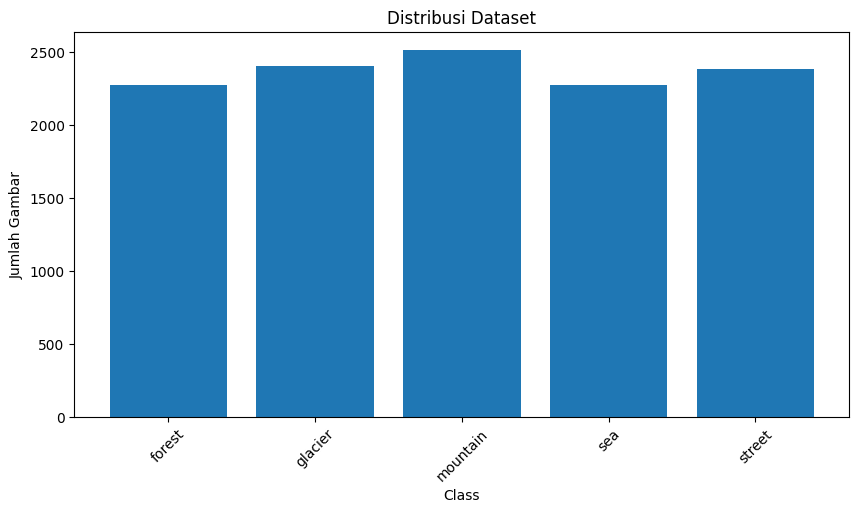

In [11]:
plt.figure(figsize=(10,5))

plt.bar(
    image_count.keys(),
    image_count.values()
)

plt.title('Distribusi Dataset')
plt.xlabel('Class')
plt.ylabel('Jumlah Gambar')

plt.xticks(rotation=45)

plt.show()

Berdasarkan visualisasi distribusi dataset, jumlah gambar pada setiap kelas
relatif seimbang dengan rentang sekitar 2200–2500 gambar per kelas.

Kondisi ini membantu model melakukan proses pembelajaran secara lebih stabil
karena tidak terdapat perbedaan jumlah data yang terlalu signifikan antar kelas.

Kelas mountain memiliki jumlah gambar terbanyak, sedangkan kelas forest
dan sea memiliki jumlah gambar yang hampir sama.

#### Visualisasi Sample Gambar

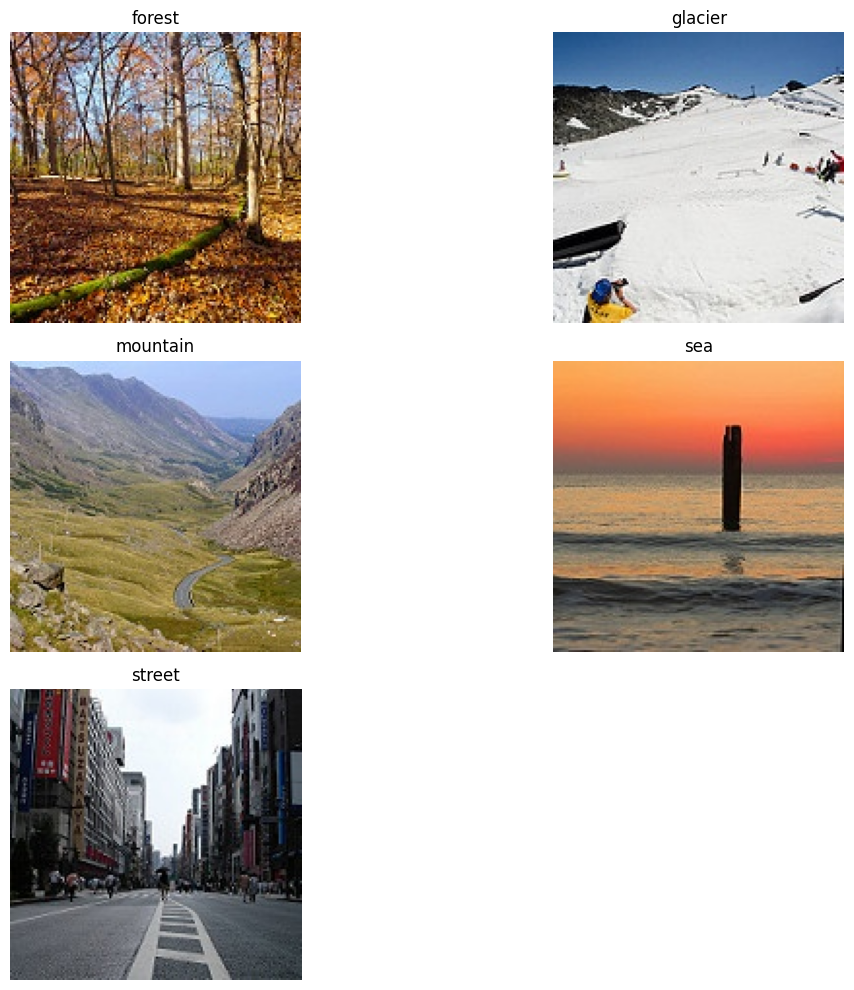

In [12]:
plt.figure(figsize=(12,10))

for i, cls in enumerate(classes):

    img_path = os.path.join(
        base_dir,
        cls,
        os.listdir(os.path.join(base_dir, cls))[0]
    )

    img = plt.imread(img_path)

    plt.subplot(3,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis('off')

plt.tight_layout()

plt.show()

Visualisasi sample gambar menunjukkan bahwa setiap kelas memiliki karakteristik
visual yang berbeda.

Kelas forest didominasi warna hijau dan pepohonan,
kelas glacier memiliki area bersalju,
kelas mountain memiliki kontur pegunungan,
kelas sea memiliki dominasi area air,
sedangkan kelas street menampilkan lingkungan perkotaan.

Perbedaan pola visual ini membantu model dalam mempelajari fitur unik
dari masing-masing kategori gambar.

### Data Preprocessing

#### Menentukan Parameter Dataset

In [13]:
IMG_SIZE = (128,128)
BATCH_SIZE = 16
SEED = 42

#### Split Dataset

In [14]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.3,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 11843 files belonging to 5 classes.
Using 8291 files for training.


#### Validation dan Test Dataset

In [15]:
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.3,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 11843 files belonging to 5 classes.
Using 3552 files for validation.


#### Membagi Validation dan Test Set

In [16]:
val_batches = tf.data.experimental.cardinality(
    val_test_ds
)

test_ds = val_test_ds.take(
    val_batches // 2
)

val_ds = val_test_ds.skip(
    val_batches // 2
)

#### Menampilkan Nama Kelas

In [17]:
class_names = train_ds.class_names
class_names

['forest', 'glacier', 'mountain', 'sea', 'street']

#### Data Augmentation

In [18]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.03
    ),

    tf.keras.layers.RandomZoom(
        0.03
    )

], name='data_augmentation')

#### Menerapkan Augmentasi Hanya pada Training Set

In [19]:
train_ds = train_ds.map(
    lambda x, y: (
        data_augmentation(x, training=True),
        y
    )
)

#### Optimasi Dataset

In [20]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(200) \
                   .prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)

## Modelling

Model CNN dibangun menggunakan arsitektur Sequential dengan beberapa layer Conv2D dan MaxPooling2D.

Layer convolution digunakan untuk mengekstraksi fitur visual dari gambar, sedangkan pooling digunakan untuk mengurangi dimensi fitur agar model lebih efisien.

GlobalAveragePooling2D digunakan untuk mengurangi jumlah parameter model sehingga model lebih ringan dan lebih cepat saat deployment.

#### Transfer Learning MobileNetV2

In [21]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Freeze Base Model

In [22]:
base_model.trainable = False

#### Membangun Model Sequential

In [23]:
model = tf.keras.Sequential([

    tf.keras.Input(shape=(128,128,3)),

    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

#### Model Summary

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Arsitektur model menggunakan pendekatan Transfer Learning
dengan MobileNetV2 sebagai feature extractor.

Layer GlobalAveragePooling2D digunakan untuk mengurangi jumlah parameter
agar model lebih ringan dan efisien.

Layer Dense 256 neuron digunakan untuk mempelajari pola fitur
yang lebih kompleks sebelum proses klasifikasi akhir dilakukan
menggunakan layer softmax.

#### Compile Model

##### Compile Arsitektur Model

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Callback

##### EarlyStopping

In [26]:
earlystop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

##### Reduce Learning Rate

In [27]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

##### Model Checkpoint

In [28]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

##### Menggabungkan Callback

In [29]:
callbacks = [
    earlystop,
    reduce_lr,
    checkpoint
]

#### Training Model

In [30]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 162s 273ms/step - accuracy: 0.8346 - loss: 0.4299 - val_accuracy: 0.8964 - val_loss: 0.2704 - learning_rate: 1.0000e-04
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 167s 290ms/step - accuracy: 0.9010 - loss: 0.2679 - val_accuracy: 0.9161 - val_loss: 0.2250 - learning_rate: 1.0000e-04
Epoch 3/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 203s 295ms/step - accuracy: 0.9109 - loss: 0.2347 - val_accuracy: 0.9167 - val_loss: 0.2187 - learning_rate: 1.0000e-04
Epoch 4/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 184s 259ms/step - accuracy: 0.9210 - loss: 0.2143 - val_accuracy: 0.9229 - val_loss: 0.2108 - learning_rate: 1.0000e-04
Epoch 5/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 198s 252ms/step - accuracy: 0.9264 - loss: 0.1940 - val_accuracy: 0.9167 - val_loss: 0.2184 - learning_rate: 1.0000e-04
Epoch 6/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 201s 250ms/step - accuracy: 0.9331 - loss: 0.1814 - val_accuracy: 0.9206 - val_loss: 0.2216 - learning_rate: 1.0000e-04
Epoch 7/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 

Hasil training menunjukkan bahwa akurasi training dan validation
mengalami peningkatan secara konsisten pada setiap epoch.

Validation accuracy berhasil mencapai lebih dari 92%,
menunjukkan bahwa model mampu melakukan generalisasi
dengan cukup baik terhadap data baru.

Nilai loss juga mengalami penurunan yang stabil,
menandakan proses pembelajaran model berjalan optimal.

## Evaluasi dan Visualisasi

#### Evaluasi Model

In [31]:
train_loss, train_acc = model.evaluate(
    train_ds,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    test_ds,
    verbose=0
)

print(f'Train Accuracy : {train_acc*100:.2f}%')
print(f'Test Accuracy  : {test_acc*100:.2f}%')

Train Accuracy : 95.40%
Test Accuracy  : 91.55%


#### Plot Accuracy

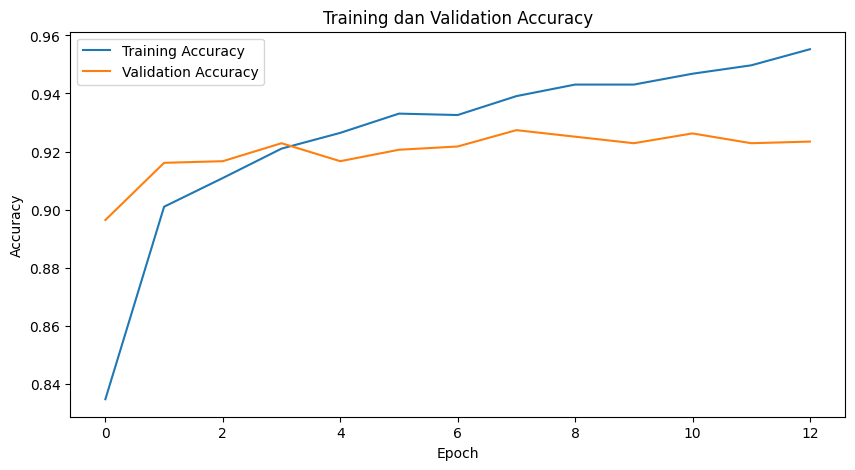

In [32]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training dan Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

Grafik accuracy menunjukkan bahwa performa model meningkat secara bertahap
selama proses training.

Kurva training dan validation accuracy memiliki pola yang relatif berdekatan,
menandakan model tidak mengalami overfitting yang signifikan.

Hal ini menunjukkan bahwa data augmentation dan callback
berhasil membantu model melakukan generalisasi dengan baik.

#### Plot Loss

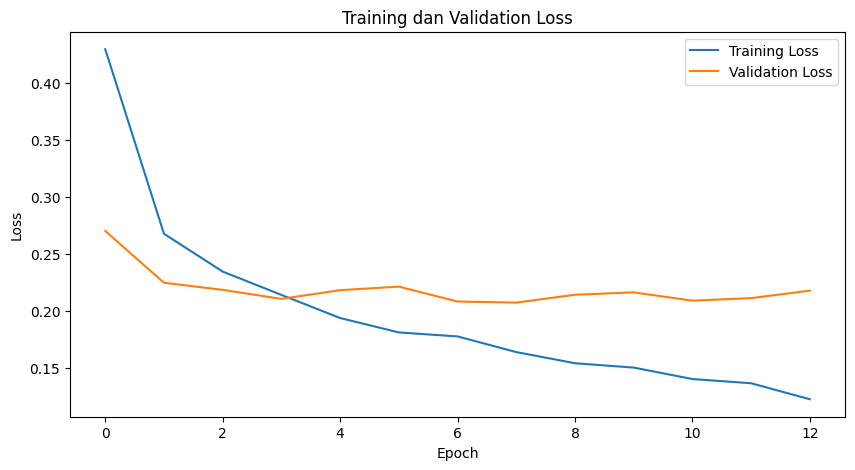

In [33]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training dan Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

Grafik loss menunjukkan penurunan nilai loss pada data training
maupun validation.

Penurunan loss yang stabil menunjukkan bahwa model berhasil
mempelajari pola data dengan baik.

Tidak terdapat lonjakan validation loss yang ekstrem,
sehingga model masih tergolong stabil selama proses training.

#### Confusion Matrix

In [34]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

#### Visualisasi Confusion Matrix

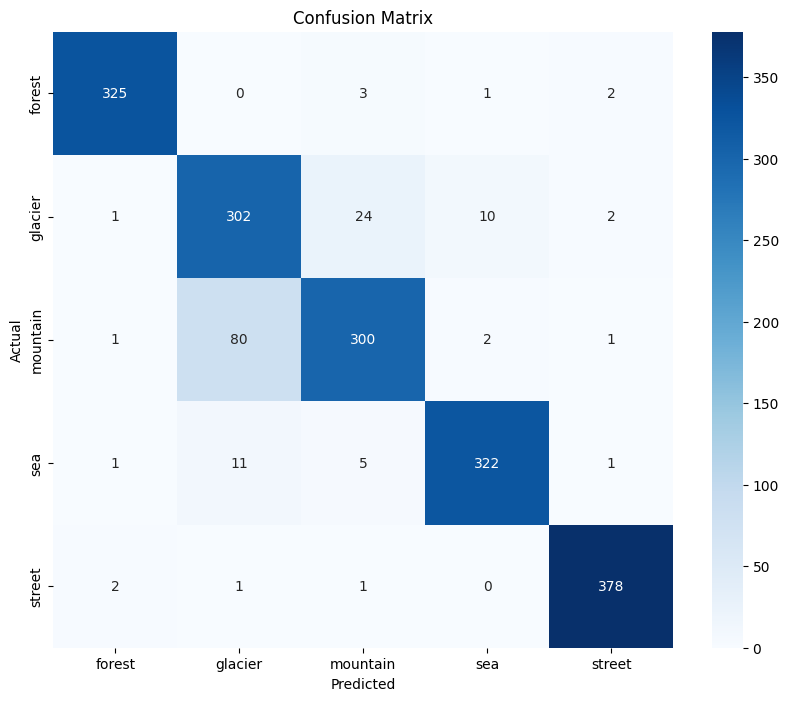

In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

Confusion matrix menunjukkan bahwa sebagian besar gambar
berhasil diklasifikasikan dengan benar.

Kelas forest dan street memiliki tingkat prediksi yang sangat baik
dengan jumlah kesalahan yang sangat kecil.

Beberapa kesalahan prediksi masih terjadi antara kelas glacier
dan mountain karena kedua kelas memiliki karakteristik visual
yang cukup mirip pada beberapa gambar.

Secara keseluruhan model mampu mempertahankan performa klasifikasi
yang baik pada seluruh kelas dataset.

#### Classification Report

In [36]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      forest       0.98      0.98      0.98       331
     glacier       0.77      0.89      0.82       339
    mountain       0.90      0.78      0.84       384
         sea       0.96      0.95      0.95       340
      street       0.98      0.99      0.99       382

    accuracy                           0.92      1776
   macro avg       0.92      0.92      0.92      1776
weighted avg       0.92      0.92      0.92      1776



Berdasarkan classification report,
model memperoleh precision, recall, dan f1-score yang tinggi
pada sebagian besar kelas.

Kelas street memiliki performa terbaik dengan nilai hampir sempurna,
sedangkan kelas glacier dan mountain memiliki performa sedikit lebih rendah
karena kemiripan fitur visual antar kelas.

Nilai weighted average sebesar 92% menunjukkan bahwa model
memiliki performa klasifikasi yang baik secara keseluruhan.

## Konversi Model

#### Save SavedModel

In [37]:
model.export('saved_model')

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_158')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138062729663248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062729669008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062729669968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062729669584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062729668816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062729668432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062729671888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062729672080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062729670928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062729669200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138062729671120

## Konversi TensorFlow Lite

#### Convert TensorFlow Lite

In [38]:
converter = tf.lite.TFLiteConverter.from_saved_model(
    'saved_model'
)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

tflite_model = converter.convert()

### Membuat Folder tflite

In [39]:
os.makedirs('tflite', exist_ok=True)

### Membuat Model tiflite

In [40]:
with open('tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

## Konversi TensorFlowJS

### Convert TFJS

In [41]:
tfjs.converters.save_keras_model(
    model,
    "tfjs_model"
)

failed to lookup keras version from the file,
    this is likely a weight only file


## Verifikasi TensorFlow Lite

### Load Interpreter

In [42]:
interpreter = tf.lite.Interpreter(
    model_path='tflite/model.tflite'
)

interpreter.allocate_tensors()

print('TFLite berhasil diverifikasi')

TFLite berhasil diverifikasi


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### Membuat label.txt

#### Save Label

In [43]:
with open('tflite/label.txt', 'w') as f:

    for label in class_names:
        f.write(label + '\n')

print("label.txt berhasil dibuat")

label.txt berhasil dibuat


## Inference (Optional)

#### Upload Gambar Baru

In [44]:
from google.colab import files

uploaded = files.upload()

Saving 20056.jpg to 20056.jpg


#### Load dan Preprocessing Gambar

In [45]:
img_path = list(uploaded.keys())[0]

img = image.load_img(
    img_path,
    target_size=(150,150)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

#### Prediksi Gambar

In [46]:
prediction = model.predict(
    img_array,
    verbose=0
)

predicted_class = class_names[
    np.argmax(prediction)
]

confidence = np.max(prediction) * 100

print(f'Prediction : {predicted_class}')
print(f'Confidence : {confidence:.2f}%')

Prediction : forest
Confidence : 100.00%


#### Visualisasi Hasil Prediksi

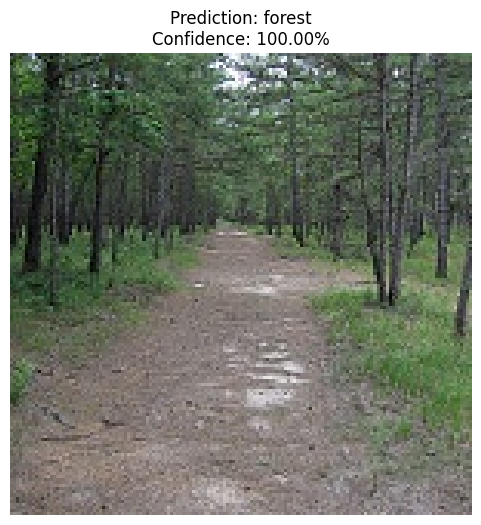

In [47]:
plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title(
    f'Prediction: {predicted_class}\n'
    f'Confidence: {confidence:.2f}%'
)

plt.axis('off')

plt.show()

Hasil inference menunjukkan bahwa model mampu mengenali gambar baru
dengan tingkat confidence yang sangat tinggi.

Model berhasil memprediksi gambar sebagai kelas forest
dengan confidence mencapai 100%.

Hal ini menunjukkan bahwa model telah berhasil mempelajari
fitur visual utama dari masing-masing kategori gambar.

## Kesimpulan

Pada proyek ini berhasil dibangun model klasifikasi gambar
menggunakan pendekatan Deep Learning berbasis
Convolutional Neural Network (CNN)
dengan metode Transfer Learning menggunakan arsitektur MobileNetV2.

Dataset yang digunakan terdiri dari lima kategori,
yaitu forest, glacier, mountain, sea, dan street
dengan total lebih dari 11 ribu gambar.

Tahapan preprocessing dilakukan dengan resize gambar,
split dataset, serta data augmentation
untuk meningkatkan kemampuan generalisasi model.

Model berhasil mencapai:
- training accuracy sebesar 95.40%
- testing accuracy sebesar 91.55%

Hasil tersebut menunjukkan bahwa model mampu melakukan
klasifikasi gambar dengan performa yang baik.

Evaluasi menggunakan confusion matrix dan classification report
menunjukkan bahwa sebagian besar gambar berhasil diprediksi
dengan benar pada seluruh kelas.

Selain itu, model berhasil dikonversi ke:
- SavedModel
- TensorFlow Lite
- TensorFlow.js

sehingga dapat digunakan pada berbagai platform deployment
seperti cloud, mobile, maupun browser.

Berdasarkan seluruh hasil evaluasi,
model yang dibangun telah memenuhi kriteria submission
dan mampu melakukan klasifikasi gambar
secara cukup akurat dan stabil.

## Membuat requirements.txt

In [48]:
!pip freeze > requirements.txt